In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
columns = []

with open("/content/communities.names", "r", encoding="latin1") as file:
    for line in file:
        if line.lower().startswith("@attribute"):
            columns.append(line.split()[1])

print("Number of columns:", len(columns))

Number of columns: 128


In [4]:
df = pd.read_csv(
    "/content/communities.data",
    header=None,
    names=columns,
    na_values="?",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   state  county  community        communityname  fold  population  \
0      8     NaN        NaN         Lakewoodcity     1        0.19   
1     53     NaN        NaN          Tukwilacity     1        0.00   
2     24     NaN        NaN         Aberdeentown     1        0.00   
3     34     5.0    81440.0  Willingborotownship     1        0.04   
4     42    95.0     6096.0    Bethlehemtownship     1        0.01   

   householdsize  racepctblack  racePctWhite  racePctAsian  ...  LandArea  \
0           0.33          0.02          0.90          0.12  ...      0.12   
1           0.16          0.12          0.74          0.45  ...      0.02   
2           0.42          0.49          0.56          0.17  ...      0.01   
3           0.77          1.00          0.08          0.12  ...      0.02   
4           0.55          0.02          0.95          0.09  ...      0.04   

   PopDens  PctUsePubTrans  PolicCars  PolicOperBudg  LemasPctPolicOnPatr  \
0     0.26

In [5]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

Shape of dataset: (1994, 128)

Column names:
['state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize', 'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'Pc

In [6]:
print("Total missing values:", df.isnull().sum().sum())

print("\nMissing values in each column:")
print(df.isnull().sum())

Total missing values: 39202

Missing values in each column:
state                     0
county                 1174
community              1177
communityname             0
fold                      0
                       ... 
LemasPctPolicOnPatr    1675
LemasGangUnitDeploy    1675
LemasPctOfficDrugUn       0
PolicBudgPerPop        1675
ViolentCrimesPerPop       0
Length: 128, dtype: int64


In [7]:
X = df.iloc[:, 5:].copy()

# Make sure all values are numeric
X = X.apply(pd.to_numeric, errors="coerce")

print("Shape before preprocessing:", X.shape)

Shape before preprocessing: (1994, 123)


In [8]:
X = X.dropna(axis=1, how="all")

print("Shape after removing completely empty columns:", X.shape)

Shape after removing completely empty columns: (1994, 123)


In [9]:
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

print("Missing values before imputation:", X.isnull().sum().sum())
print("Missing values after imputation:", np.isnan(X_imputed).sum())

Missing values before imputation: 36851
Missing values after imputation: 0


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (1994, 123)


In [11]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA data shape:", X_pca.shape)

PCA data shape: (1994, 123)


In [12]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance of each component:")
print(explained_variance)

Explained variance of each component:
[2.14830355e-01 1.46046980e-01 9.35507517e-02 6.66239051e-02
 5.65047943e-02 3.65819048e-02 3.26059258e-02 3.03834072e-02
 2.49044462e-02 1.79185672e-02 1.70234043e-02 1.38151163e-02
 1.32324251e-02 1.27058233e-02 1.18430853e-02 1.12113532e-02
 1.06659750e-02 8.68956980e-03 8.63969484e-03 8.16638815e-03
 7.84280803e-03 7.30065202e-03 7.20750023e-03 7.09120898e-03
 6.50895245e-03 6.08868309e-03 5.87895610e-03 5.34398862e-03
 5.15694331e-03 4.90578671e-03 4.76245072e-03 4.43567063e-03
 4.20818579e-03 4.13367231e-03 3.97326540e-03 3.84731942e-03
 3.69123705e-03 3.45362741e-03 3.25490749e-03 3.12935135e-03
 3.04415388e-03 2.99452462e-03 2.87367301e-03 2.68001768e-03
 2.49684482e-03 2.43731625e-03 2.33690209e-03 2.16863070e-03
 2.04615440e-03 1.92234966e-03 1.84020837e-03 1.78243882e-03
 1.66817015e-03 1.61153989e-03 1.57934230e-03 1.53122162e-03
 1.44660798e-03 1.36302370e-03 1.30541171e-03 1.25604566e-03
 1.19835923e-03 1.14343330e-03 1.10815551e-03 1

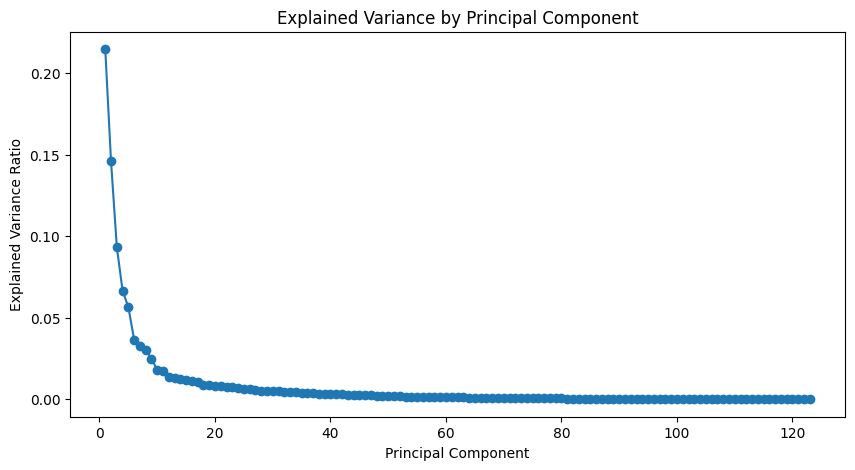

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Component")

plt.show()

In [14]:
cumulative_variance = np.cumsum(explained_variance)

print("Cumulative explained variance:")
print(cumulative_variance)

Cumulative explained variance:
[0.21483036 0.36087734 0.45442809 0.52105199 0.57755679 0.61413869
 0.64674462 0.67712802 0.70203247 0.71995104 0.73697444 0.75078956
 0.76402198 0.77672781 0.78857089 0.79978225 0.81044822 0.81913779
 0.82777749 0.83594387 0.84378668 0.85108733 0.85829483 0.86538604
 0.87189499 0.87798368 0.88386263 0.88920662 0.89436357 0.89926935
 0.9040318  0.90846747 0.91267566 0.91680933 0.9207826  0.92462992
 0.92832115 0.93177478 0.93502969 0.93815904 0.94120319 0.94419772
 0.94707139 0.94975141 0.95224825 0.95468557 0.95702247 0.9591911
 0.96123726 0.96315961 0.96499982 0.96678225 0.96845042 0.97006196
 0.97164131 0.97317253 0.97461914 0.97598216 0.97728757 0.97854362
 0.97974198 0.98088541 0.98199357 0.98299634 0.9839074  0.98477257
 0.98561828 0.98646042 0.98725557 0.98795028 0.98860997 0.9892247
 0.98982587 0.99041564 0.99098346 0.99151611 0.99203609 0.9925439
 0.99303983 0.9935008  0.99391003 0.99429405 0.99467366 0.99502484
 0.99535853 0.99568974 0.99600968 

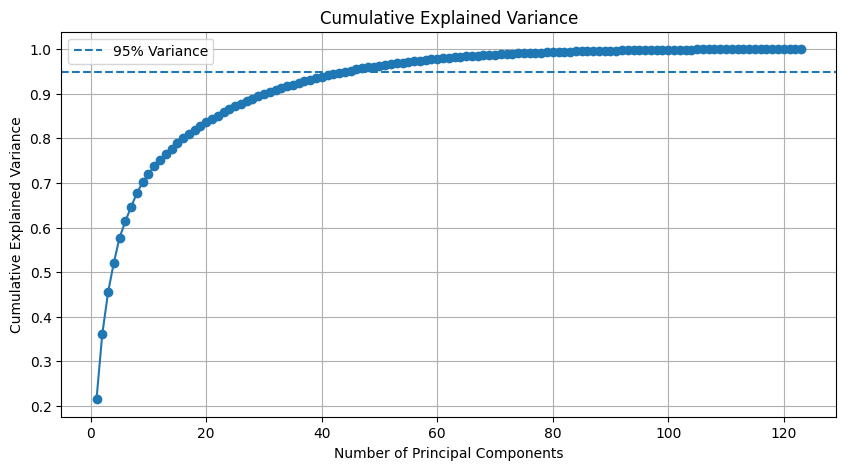

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid()

plt.show()

In [16]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components needed for 95% variance:", n_components)

Number of components needed for 95% variance: 45


In [17]:
pca_reduced = PCA(n_components=n_components)

X_reduced = pca_reduced.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape)
print("Reduced dimensions:", X_reduced.shape)

Original dimensions: (1994, 123)
Reduced dimensions: (1994, 45)


In [18]:
pca_columns = [
    "PC" + str(i)
    for i in range(1, n_components + 1)
]

df_pca = pd.DataFrame(
    X_reduced,
    columns=pca_columns
)

print(df_pca.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  1.702796 -0.738582  2.166079 -2.406092 -0.825983 -4.121150  0.780554   
1 -1.564543  0.257813  1.122003 -5.069605  2.039323 -3.669566  2.527208   
2 -1.825207 -2.743532 -0.061517  0.231123  0.471427 -1.385532  1.917326   
3  2.923541  2.024646 -2.066051  3.027910 -2.380926  1.166463  1.654890   
4  5.904712 -1.902934 -0.118541  2.862099 -2.021257 -0.186667  0.626082   

        PC8       PC9      PC10  ...      PC36      PC37      PC38      PC39  \
0  0.161350  0.317840  0.429595  ...  0.940252  0.756901  0.141149  0.288909   
1  1.514403  2.110313 -0.105290  ... -0.226805 -0.154264  0.288038  0.272711   
2  1.997966 -0.122818 -0.167487  ...  0.781010 -0.298090  0.540069  0.121574   
3  4.674199 -0.366974  0.926360  ...  1.213835 -2.162932  0.079252 -0.082749   
4 -0.489904  0.246059 -0.715096  ... -0.220270 -0.202287 -0.142443 -0.683676   

       PC40      PC41      PC42      PC43      PC44      PC45  
0 -0

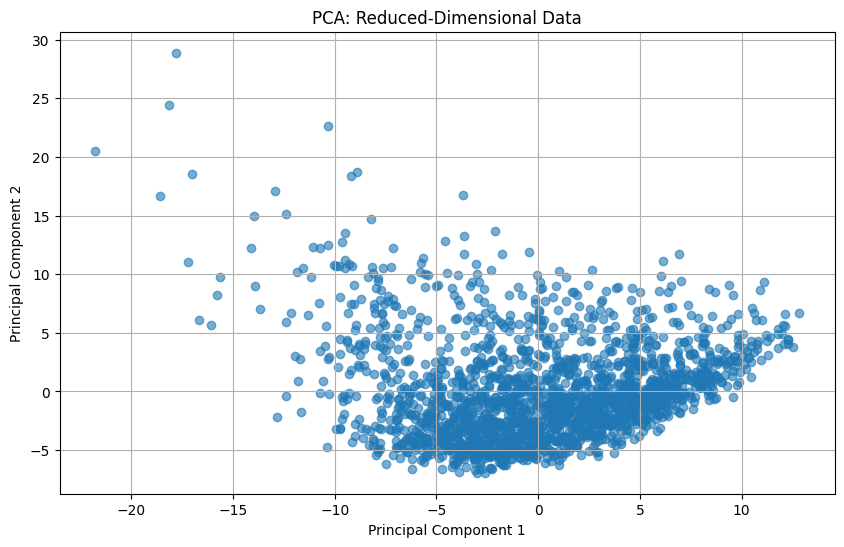

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: Reduced-Dimensional Data")

plt.grid()
plt.show()

In [20]:
print("Original number of features:", X_scaled.shape[1])
print("Reduced number of components:", X_reduced.shape[1])

print("\nOriginal shape:", X_scaled.shape)
print("Reduced shape:", X_reduced.shape)

Original number of features: 123
Reduced number of components: 45

Original shape: (1994, 123)
Reduced shape: (1994, 45)


In [21]:
print("----- PCA Interpretation -----")

print("Original number of features:", X_scaled.shape[1])
print("Reduced number of components:", X_reduced.shape[1])

print(
    "The original dataset was standardized and transformed using PCA."
)

print(
    "PCA reduced the number of features while retaining approximately 95% "
    "of the total variance."
)

print(
    "The first two principal components were used to visualize the "
    "high-dimensional data in 2D."
)

----- PCA Interpretation -----
Original number of features: 123
Reduced number of components: 45
The original dataset was standardized and transformed using PCA.
PCA reduced the number of features while retaining approximately 95% of the total variance.
The first two principal components were used to visualize the high-dimensional data in 2D.
